In [36]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('2019-Dec.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [37]:
print(df.shape)
df.info()

(3533286, 9)
<class 'pandas.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 242.6 MB


In [38]:
# pasamos la columna event_time a formato de fecha
df['event_time'] = pd.to_datetime(df['event_time'])

Ahora que sabemos que tenemos 3.5 millones de filas, necesitamos entender el comportamiento de los usuarios, vamos a medir cuantas visualizaciones, cuantas adiciones al carrito y cuantas compras reales ocurrieron en el mes de diciembre. 

In [39]:
print('Distribución de eventos:')
print(df['event_type'].value_counts())

#vamos a sacar el porcentaje exacto de cada evento para medir el embudo
print('\nPorcentaje del embudo:')
print(df['event_type'].value_counts(normalize=True) * 100)

Distribución de eventos:
event_type
view                1728331
cart                 927124
remove_from_cart     664655
purchase             213176
Name: count, dtype: int64

Porcentaje del embudo:
event_type
view                48.915684
cart                26.239710
remove_from_cart    18.811243
purchase             6.033364
Name: proportion, dtype: float64


Prácticamente la mitad de todas las acciones de los usuarios son solo mirando los productos, el 265 de las interacciones implican agregar productos al carrito, el 185 de los usuarios se arrepienten y sacan los productos de su carrito, de los 3.5 millones de interacciones que tuvimos con los usuarios, el 6% finalizó su compra con éxito, un número favorable en este caso.  

In [40]:
#Cuánto dinero total se movió en transacciones exitosas? 
total_revenue = df[df['event_type'] == 'purchase']['price'].sum()
print(f'Ingresos totales por ventas en diciembre: ${total_revenue:,.2f}')

#Cuál es el preciopromedio según las acciones del usuari?
print(f'\nPrecio promedio del producto por tipo de evento:')
print(df.groupby('event_type')['price'].mean())

Ingresos totales por ventas en diciembre: $1,077,624.85

Precio promedio del producto por tipo de evento:
event_type
cart                 5.260712
purchase             5.055095
remove_from_cart     5.323618
view                12.644267
Name: price, dtype: float64


El precio en promedio de la gente que mira es de 12.64 pero lo interesante es que lo que agregan al carrito y compran ronda los 5. Esto significa que los productos más costosos llaman la atención, la gente los mira, pero el volumen de ventas real está en los productos más económicos, el precio no parece ser la razón por la que abandonan el carrito, ya que en promedio los productos que remueven del carrito vale casi lo mismo que lo que compran. 

In [41]:
# Agrupamos por usuarios para ver quiénes son los mejores compradores
top_buyers = df[df['event_type'] == 'purchase'].groupby('user_id')['price'].sum().reset_index()

# Mostramos de mayor a menor y mostramos el top 10
top_buyers.sort_values(by='price', ascending=False).head(10)

,user_id,price
15659,575709540,1526.73
13776,565036131,1443.94
20657,586168240,1240.67
14978,572081598,1085.32
15084,572631412,1046.42
9629,531900924,1013.56
4140,442763940,1012.99
5578,471099630,960.13
2820,409977933,851.99
86,150318419,851.89


In [42]:
# vamos a buscar las 5 marcas que más ingresos le trajeron a la empresa 
top_brands = df[df['event_type'] == 'purchase'].groupby('brand')['price'].sum().reset_index()
top_brands.sort_values(by='price', ascending=False).head(5)

,brand,price
184,runail,58177.26
86,grattol,43793.50
97,irisk,35291.51
211,uno,29084.76
69,estel,24474.19


Ya sabemos que compran nuestros clientes, ahora buscaremos que días de la semana prefiere comprar la gente, saber qué días hay más ventas es importante para planear acciones como campañas de marketing o promociones.  

In [52]:
df['day_of_week'] = df['event_time'].dt.day_name()
purchases_by_day = df[df['event_type'] == 'purchase'].groupby('day_of_week').size().reset_index(name='total_purchases')

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

purchases_by_day['day_of_week'] = pd.Categorical(purchases_by_day['day_of_week'], categories=days_order, ordered=True)
purchases_by_day = purchases_by_day.sort_values('day_of_week')

purchases_by_day

,day_of_week,total_purchases
1,Monday,37171
5,Tuesday,34463
6,Wednesday,32250
4,Thursday,30220
0,Friday,26193
2,Saturday,22450
3,Sunday,30429


En este caso, la gente compra más apenas arranca la jornada laboral, es decir a inicios de semana, los lunes y martes son los días que más compran, por intuición diríamos que serían los fines de semana cuando la gente compra más, pero no es así, podríamos deducir que a inicios de semana se pueden programar pautas publicitarias con más impacto que los fines de semana. 
Ahora que ya sabemos los días con más ventas, necesitamos saber a qué hora exacta del día se producen las ventas.  

In [44]:
df['hour'] = df['event_time'].dt.hour
purchases_by_hour = df[df['event_type'] == 'purchase'].groupby('hour').size().reset_index(name='total_purchases')

purchases_by_hour.sort_values(by='total_purchases', ascending=False).head(5)

,hour,total_purchases
11,11,14850
10,10,13894
12,12,13138
9,9,12642
13,13,12455


Los datos nos muestran que la hora pico más fuerte ocurre a mitad de la mañana, entre las 10:00 y las 12:00 del mediodía, como sabemos que los días fuertes en ventas son a inicios de semana podemos deducir que los clientes están comprando en el horario de descanso o almuerzo en su trabajo o universidad.
Ahora vamos a encontrar el ticket promedio.   

In [45]:
only_purchases = df[df['event_type'] == 'purchase']
average_ticket = only_purchases['price'].mean()

print(f'El ticket promedio de compra en la tienda es: ${average_ticket:.2f}')


El ticket promedio de compra en la tienda es: $5.06


Ahora vamos a calcular el porcentaje de efectividad del carrito, sabemos que la gente mete muchos productos al carrito, pero ¿cuántos de estos realmente se convierten en ventas?    

In [46]:
total_carts = df[df['event_type'] == 'cart'].shape[0]
total_purchases = df[df['event_type'] == 'purchase'].shape[0]

cart_conversion_rate = (total_purchases / total_carts) * 100

print(f'Tasa de conversión de carrito a compra: {cart_conversion_rate:.2f}')

Tasa de conversión de carrito a compra: 22.99


Tener como resultado casi el 23 % es un resultado excelente, significa que de cada 100 personas que entraron y seleccionaron algún producto, 23 de ellas terminaron pagando y completando su compra. El restante abandono su carrito, así que vamos a ver cuánto dinero no se facturo por ese abandono.
Vamos a calcular cuánto dinero sumaban los productos que la gente metió al carrito pero que nunca llegó a comprar. Esto nos dirá el tamaño de la oportunidad perdida.

In [47]:
revenue_in_cart = df[df['event_type'] == 'cart']['price'].sum()
revenue_purchased = df[df['event_type'] == 'purchase']['price'].sum()
abandoned_revenue = revenue_in_cart - revenue_purchased

print(f'Dinero total en carritos: ${revenue_in_cart:,.2f}')
print(f'Dinero total vendido: ${revenue_purchased:,.2f}')
print(f'ventas potenciales perdidas por abandono del carrito: ${abandoned_revenue:,.2f}')



Dinero total en carritos: $4,877,332.39
Dinero total vendido: $1,077,624.85
ventas potenciales perdidas por abandono del carrito: $3,799,707.54


Vaya detalle que nos encontramos, aunque decíamos que un 23% de ventas reales era un buen numero al darnos cuenta de la realidad la tienda dejo ir, no facturo teniendo la oportunidad 3.7 millones de dólares en carritos abandonados, todo esto en solo un mes. ¿Qué podríamos hacer? Tenemos datos muy importantes y nos faltan muchos más, pero con el día y hora en las que sabemos que son más altas las ventas podemos atacar con correos automatizados o ¿Por qué no? Con descuentos directos personalizados.      
En nuestra búsqueda de más información ahora vamos a ver el top de productos más abandonados en el carrito. 

In [48]:
only_carts = df[df['event_type'] == 'cart']
# acá agrupamos por ID del producto
abandoned_products = only_carts.groupby('product_id').size().reset_index(name='times_added')

abandoned_products.sort_values(by='times_added', ascending=False).head(5)


,product_id,times_added
13271,5809910,6513
11994,5802432,5081
4897,5700037,4978
23102,5854897,4078
14695,5815662,3047


Ya que tenemos identificados los ID de los productos que más dejaron abandonados en el carrito podemos identificar problemas de diferentes maneras, podemos ver si hay problemas de envió por ejemplo, si algún maquillaje delicado o algo pesado que haga que el costo de envió se incremente y los clientes prefieran dejarlo o también puede ser problema de stock, donde el cliente quiera comprarlo pero en ese instante ya no haya en stock, como científicos debemos identificar esto con nuestro equipo y decidir de qué manera podemos abordar el problema.
Pero antes de buscar posibles soluciones vamos a ver por qué se abandonan en el carrito.  


In [49]:
only_purchases = df[df['event_type'] == 'purchase']
# acá agrupamos las compras por ID y contamos cuantas ventas tuvo cada uno
sales_by_product = only_purchases.groupby('product_id').size().reset_index(name='times_purchased')

# filtramos solo para ver los 5 productos más abandonados
top_abandoned_ids = [5809910, 5802432, 5700037, 5854897, 5815662]
sales_by_product[sales_by_product['product_id'].isin(top_abandoned_ids)]


,product_id,times_purchased
4282,5700037,621
9936,5802432,714
10916,5809910,1659
11958,5815662,521
17698,5854897,786


Que resultado, vemos, aunque la venta real de estos artículos que abandonan en el carrito es baja en comparación con las veces que es añadido al carrito, no es tan baja como lo imaginamos, es decir, a final del mes se venden y no en una cantidad baja como creemos, esto nos insinúa que los clientes usan su carrito como una lista de deseos, guardan sus favoritos o calculan sus precios, pero al final tenemos ventas registradas.   

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18152\4055374273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week', y='total_purchases', data=purchases_by_day, palette='Blues_r')


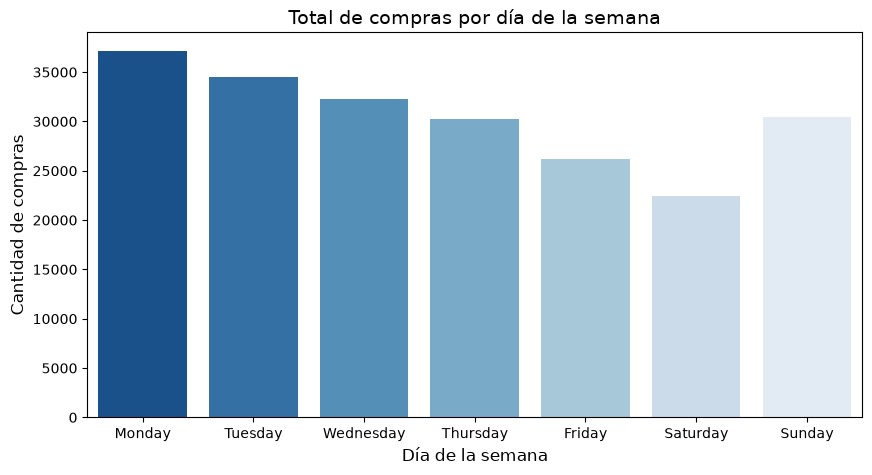

In [53]:
plt.figure(figsize=(10,5))

sns.barplot(x='day_of_week', y='total_purchases', data=purchases_by_day, palette='Blues_r')

plt.title('Total de compras por día de la semana', fontsize=14)
plt.xlabel('Día de la semana', fontsize=12)
plt.ylabel('Cantidad de compras', fontsize=12)

plt.show()

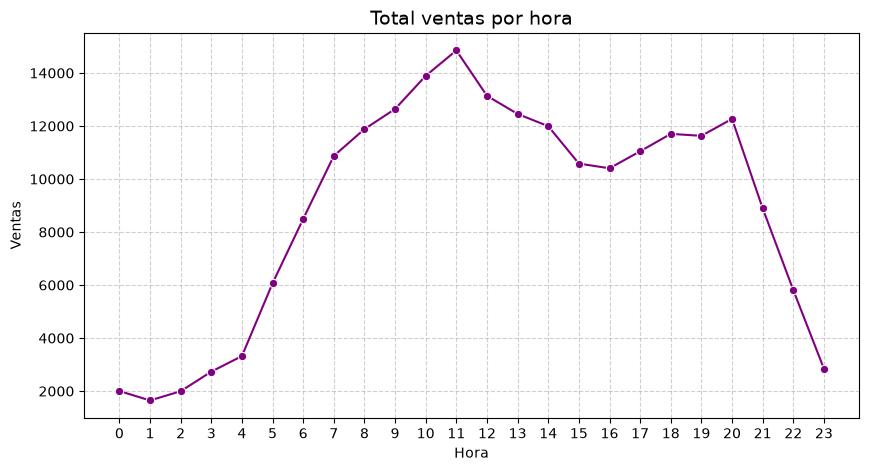

In [54]:
plt.figure(figsize=(10,5))

sns.lineplot(x='hour', y='total_purchases', data=purchases_by_hour, marker='o', color='purple')

plt.title('Total ventas por hora', fontsize=14)
plt.xlabel('Hora')
plt.ylabel('Ventas')

plt.xticks(purchases_by_hour['hour'])
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [55]:
# CReación del perfil de clientes para modelado 
customer_purchases = df[df['event_type'] == 'purchase']
customer_profiles = customer_purchases.groupby('user_id').agg({
    'event_type': 'size',
    'price': 'sum'
}).reset_index()

customer_profiles.columns = ['user_id', 'total_transactions', 'total_spent']

customer_profiles.head()

,user_id,total_transactions,total_spent
0,12055855,4,16.54
1,15400971,3,35.71
2,25392526,3,22.14
3,28129653,23,81.05
4,31647175,2,15.88
